# Capa 2 — Intereses, hábitos y aspiraciones de las juventudes

Qué hacen los jóvenes en su tiempo, qué consumen, qué les interesa, qué quieren aprender y qué les impide
participar. Para reproducirlo:

```bash
python scripts/capa2_uso_tiempo_enut.py descargar && python scripts/capa2_uso_tiempo_enut.py calcular
python scripts/capa2_cultura_enapres.py descargar && python scripts/capa2_cultura_enapres.py calcular
python scripts/capa2_educacion_internet_enaho.py descargar && python scripts/capa2_educacion_internet_enaho.py calcular
```

### Tipos de evidencia

| Tipo | Fuentes | Qué permite afirmar |
|---|---|---|
| **Representativa, cálculo propio** | ENUT 2024, ENAPRES 2022–2025 (cultura), ENAHO 2022–2025 (educación e internet), microdatos del INEI | Estimaciones para Lima Metropolitana y el país. **Lima Este** (7 distritos juntos) es un *dominio no planificado* por el INEI: se publica solo si el CV ≤ 25 %; entre 15 % y 25 % es **referencial**. Nunca por distrito. |
| **Estudios de mercado** | Ipsos 2019, 2020, 2022 | Jóvenes del Perú urbano (13–20 o 18–25 años), antes de 2023. Sirven para identificar dimensiones, **no describen a Lima Este hoy**. |
| **Señales exploratorias** | Programa de Voluntariado, RENOJ (Capa 1) | Personas u organizaciones autoseleccionadas. **No se generalizan.** |

En las tablas: `r` = referencial (CV entre 15 % y 25 %); vacío = no publicable (CV > 25 %).
Lima Este forma parte de Lima Metropolitana; las diferencias entre ambas se leen con sus intervalos de confianza.
Metodología detallada: `fuentes/metodologia_capa2.md`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 200)
P = Path("..") / "data" / "processed"
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRIS_SERIE, TINTA, TINTA_2, GRILLA, EJE, FONDO = "#b5b3ab", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "axes.edgecolor": EJE, "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 110,
})

def marca(df):
    '''Valor con marca de precisión: "r" referencial; vacío si no es publicable.'''
    v = df["valor_publicable"].round(1).astype(str)
    return np.where(df["precision"] == "referencial", v + " r", np.where(df["precision"] == "no_publicable", "", v))

def tabla(df, filas, columnas):
    d = df.assign(texto=marca(df))
    return d.pivot_table(index=filas, columns=columnas, values="texto", aggfunc="first").fillna("")

def puntos(ax, datos, categorias, series, xlabel, titulo, ic=False):
    '''Gráfico de puntos: una fila por categoría, una marca por serie (máx. 3 series).'''
    y = np.arange(len(categorias))
    for (nombre, color, hueco), desp in zip(series, [-0.18, 0, 0.18][:len(series)] if len(series) == 3 else [-0.12, 0.12]):
        d = datos[nombre].reindex(categorias)
        if ic and f"{nombre}_ee" in datos:
            ee = datos[f"{nombre}_ee"].reindex(categorias)
            ax.hlines(y + desp, d - 1.96 * ee, d + 1.96 * ee, color=color, lw=1.5, alpha=0.6)
        ax.scatter(d, y + desp, s=44, color=FONDO if hueco else color, edgecolor=color, linewidth=1.6,
                   zorder=3, label=nombre)
    ax.set_yticks(y, categorias); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f} %"); ax.set_xlabel(xlabel); ax.set_title(titulo)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5)

## 1. Uso del tiempo — ENUT 2024

Diario de 144 franjas de 10 minutos (día de semana, sábado y domingo). Se considera que una persona
"realizó" una actividad si esta aparece en su semana tipo. Un solo año (2024).

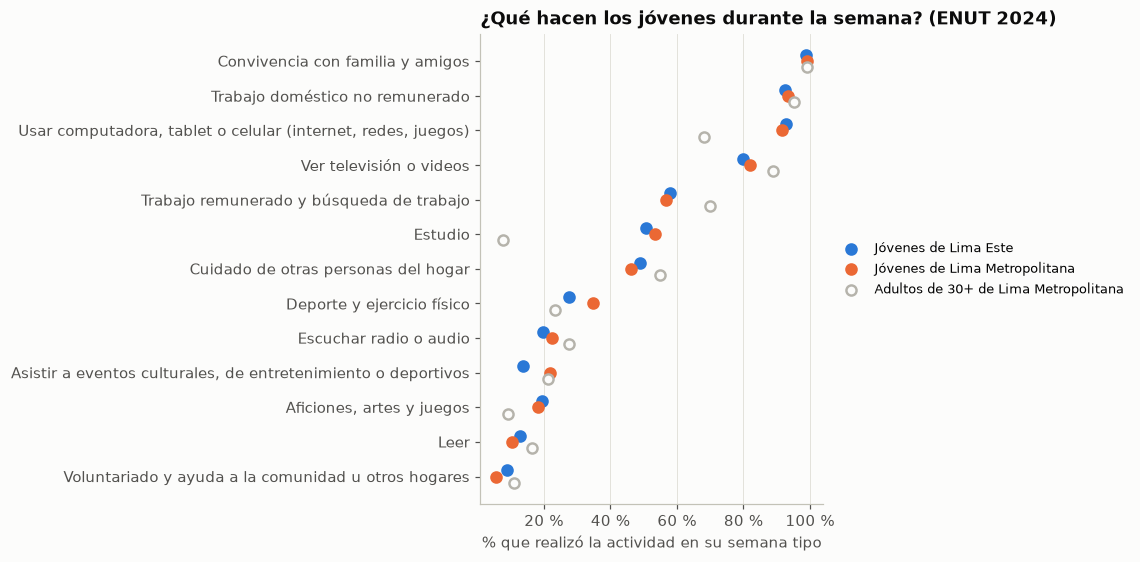

Horas semanales entre quienes realizan la actividad:


nivel_geografico                                              lima_este lima_metropolitana       nacional      
grupo_edad                                                        15-29              15-29   30+    15-29   30+
categoria                                                                                                      
Aficiones, artes y juegos                                         7.5 r                8.3   7.6      7.5   8.6
Asistir a eventos culturales, de entretenimiento o deportivos     4.9 r                5.5   5.0      5.6   5.3
Convivencia con familia y amigos                                   23.3               22.8  25.9     24.8  28.1
Cuidado de otras personas del hogar                                16.8               14.2  16.9     15.8  15.7
Deporte y ejercicio físico                                          5.7                5.9   5.3      6.2   4.7
Escuchar radio o audio                                            5.4 r                8.8  10.7      8.9  13.0
Estudio                                                            36.7               34.7   8.9     36.3  11.0
Leer                                                              5.0 r                4.9   6.5      4.5   6.8
Trabajo doméstico no remunerado                                    11.1               10.6  19.4     12.6  20.6
Trabajo remunerado y búsqueda de trabajo                           42.0               41.3  45.4     38.7  42.7
Usar computadora, tablet o celular (internet, redes, juegos)       16.2               16.3   9.8     14.3   9.1
Ver televisión o videos                                            11.0               11.6  17.0     11.2  15.3
Voluntariado y ayuda a la comunidad u otros hogares                                  5.6 r   8.9      5.8   9.1

In [2]:
enut = pd.read_csv(P / "capa2_uso_tiempo_enut.csv")
base = enut[(enut.sexo == "total") & (enut.grupo_edad.isin(["15-29", "30+"]))]
part = base[base.familia == "participacion_semanal"]
excluir = ["Dormir", "Comer y beber", "Cuidado personal, descanso y otras actividades personales",
           "Producción para autoconsumo", "Traslados al trabajo", "Traslados al estudio"]
cats = (part[(part.nivel_geografico == "lima_metropolitana") & (part.grupo_edad == "15-29") & ~part.categoria.isin(excluir)]
        .sort_values("valor", ascending=False).categoria.tolist())
def serie_enut(geo, edad, fam="participacion_semanal"):
    d = base[(base.familia == fam) & (base.nivel_geografico == geo) & (base.grupo_edad == edad)].set_index("categoria")
    return d.valor_publicable, d.ee
datos = {}
for nombre, geo, edad in [("Jóvenes de Lima Este", "lima_este", "15-29"),
                          ("Jóvenes de Lima Metropolitana", "lima_metropolitana", "15-29"),
                          ("Adultos de 30+ de Lima Metropolitana", "lima_metropolitana", "30+")]:
    datos[nombre], datos[f"{nombre}_ee"] = serie_enut(geo, edad)
fig, ax = plt.subplots(figsize=(10.5, 5.2))
puntos(ax, datos, cats, [("Jóvenes de Lima Este", AZUL, False), ("Jóvenes de Lima Metropolitana", NARANJA, False),
                          ("Adultos de 30+ de Lima Metropolitana", GRIS_SERIE, True)],
       "% que realizó la actividad en su semana tipo", "¿Qué hacen los jóvenes durante la semana? (ENUT 2024)")
plt.tight_layout(); plt.show()
print("Horas semanales entre quienes realizan la actividad:")
display(tabla(base[(base.familia == "horas_semanales_entre_participantes") & base.categoria.isin(cats)],
              "categoria", ["nivel_geografico", "grupo_edad"]))

In [3]:
dep = enut[(enut.familia == "participacion_semanal") & (enut.nivel_geografico.isin(["lima_metropolitana", "nacional"]))
           & enut.categoria.isin(["Deporte y ejercicio físico", "Aficiones, artes y juegos",
                                  "Asistir a eventos culturales, de entretenimiento o deportivos", "Leer",
                                  "Voluntariado y ayuda a la comunidad u otros hogares"])
           & (enut.grupo_edad.isin(["15-29", "15-19", "20-24", "25-29"]))]
print("Participación por sexo y edad (% que realizó la actividad en la semana)")
display(tabla(dep, "categoria", ["nivel_geografico", "grupo_edad", "sexo"]))
print("Satisfacción con el tiempo libre (% muy o totalmente satisfecho / % nada o poco satisfecho)")
sat = enut[enut.familia.str.startswith("satisfaccion") & (enut.sexo == "total") & enut.grupo_edad.isin(["15-29", "30+"])]
display(tabla(sat, ["familia", "categoria"], ["nivel_geografico", "grupo_edad"]))

Participación por sexo y edad (% que realizó la actividad en la semana)


nivel_geografico                                              lima_metropolitana                                       nacional                               
grupo_edad                                                                 15-19   15-29                 20-24   25-29    15-19  15-29             20-24 25-29
sexo                                                                       total  hombre  mujer  total   total   total    total hombre mujer total total total
categoria                                                                                                                                                     
Aficiones, artes y juegos                                                   27.1    27.0  9.1 r   18.3  18.7 r   9.8 r     18.5   20.7   7.3  14.0  14.5   8.0
Asistir a eventos culturales, de entretenimiento o deportivos               22.7    22.4   21.4   21.9  22.2 r    21.0     22.5   24.5  21.7  23.1  26.4  21.1
Deporte y ejercicio físico                                                  38.8    49.1   19.7   34.8    35.0    31.0     43.7   52.0  19.9  36.1  33.9  28.2
Leer                                                                      11.4 r  12.1 r  8.5 r   10.4          11.4 r      9.8    9.3   7.3   8.3   7.3   7.1
Voluntariado y ayuda a la comunidad u otros hogares                                5.4 r  5.8 r  5.6 r           6.3 r      8.3    7.3  10.7   9.0   8.9  10.0

Satisfacción con el tiempo libre (% muy o totalmente satisfecho / % nada o poco satisfecho)


nivel_geografico                                                         lima_este lima_metropolitana       nacional      
grupo_edad                                                                   15-29              15-29   30+    15-29   30+
familia                                  categoria                                                                        
satisfaccion_muy_o_totalmente_satisfecho Calidad del tiempo libre             34.3               40.9  34.7     37.3  28.1
                                         Cantidad de tiempo libre             40.9               47.3  39.7     43.0  33.5
                                         Tiempo dedicado a pasatiempos        45.8               50.0  41.7     44.5  33.2
                                         Tiempo dedicado a sus amistades      52.9               55.4  37.0     49.8  35.0
satisfaccion_nada_o_poco_satisfecho      Calidad del tiempo libre             33.2               27.4  36.3     29.1  37.9
                                         Cantidad de tiempo libre             30.1               25.7  34.0     26.4  35.0
                                         Tiempo dedicado a pasatiempos        36.0               28.6  35.4     28.8  38.2
                                         Tiempo dedicado a sus amistades      32.0               23.4  34.3     24.6  34.2

### 1.1 Lectura

- **Pantallas y convivencia dominan la semana.** El 92 % de los jóvenes de Lima Metropolitana usa computadora,
  tablet o celular (internet, redes, juegos) y el 82 % ve televisión o videos; entre los adultos de 30 años o más,
  el uso de dispositivos baja a 68 %.
- **Deporte y ejercicio:** 35 % de los jóvenes de Lima Metropolitana (28 % en Lima Este) lo practica en la
  semana, frente a una minoría de adultos. **La brecha por sexo es grande:** 49 % de los hombres jóvenes frente a
  20 % de las mujeres jóvenes.
- **Aficiones, artes y juegos** (18–19 %) y **asistir a eventos** culturales, de entretenimiento o deportivos
  (14–22 %) son actividades minoritarias pero más frecuentes entre jóvenes que entre adultos.
- **Leer** (10–13 %) y el **voluntariado** (6–9 %) son poco frecuentes.
- **Tiempo libre escaso o poco satisfactorio:** menos de la mitad de los jóvenes está muy o totalmente satisfecho
  con la cantidad de tiempo libre (47 % en Lima Metropolitana, 41 % en Lima Este) y alrededor de un tercio con su
  calidad. En Lima Este la insatisfacción parece mayor, sobre todo con el **tiempo para amistades** (32 % poco o
  nada satisfecho, frente a 23 %), aunque varias diferencias están cerca del margen de error.
- La mitad estudia (≈ 37 h semanales entre quienes estudian) y más de la mitad trabaja (≈ 42 h), lo que acota el
  tiempo disponible para actividades.

## 2. Participación cultural — ENAPRES 2022–2025

Personas de 14 años o más, últimos 12 meses. Para Lima Este y Lima Metropolitana se agrupan los cuatro años
(2022–2025) para tener suficiente muestra. **Validación:** la asistencia a teatro nacional (14+) de 2024 calculada
aquí es 8,6 %, igual a la publicada por el Ministerio de Cultura.

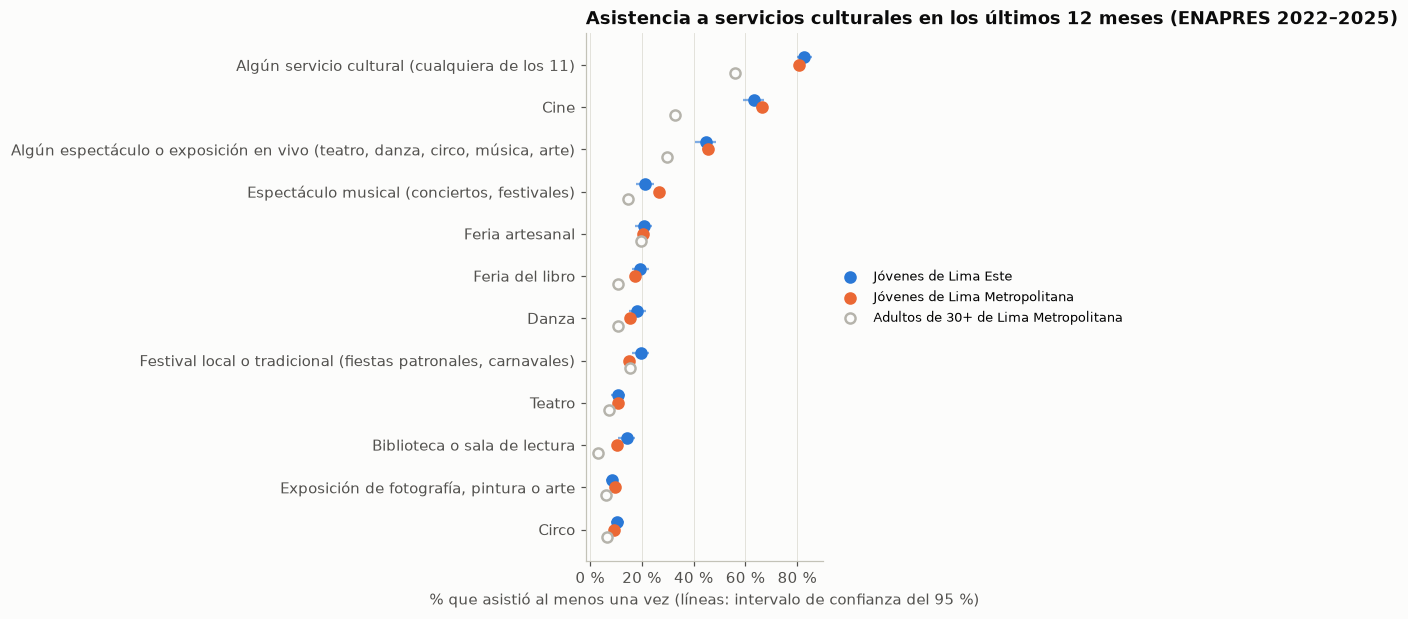

nivel_geografico                                                                  lima_este       lima_metropolitana      
grupo_edad                                                                            15-29   30+              15-29   30+
familia    item                                                                                                           
asistencia Algún espectáculo o exposición en vivo (teatro, danza, circo, músic...      44.6  29.4               45.6  29.7
           Algún servicio cultural (cualquiera de los 11)                              82.8  55.5               80.7  56.0
           Biblioteca o sala de lectura                                                14.1   4.3               10.4   3.1
           Cine                                                                        63.2  30.8               66.4  32.7
           Circo                                                                       10.6   5.7                9.2   6.5
           Danza                                                                       18.3  12.3               15.6  10.7
           Espectáculo musical (conciertos, festivales)                                21.4  15.5               26.8  14.6
           Exposición de fotografía, pintura o arte                                     8.6   5.1                9.8   6.0
           Feria artesanal                                                             20.8  18.7               20.5  19.9
           Feria del libro                                                             19.4   8.9               17.5  10.8
           Festival local o tradicional (fiestas patronales, carnavales)               19.6  17.1               15.0  15.5
           Otros servicios culturales                                                 7.3 r   4.4                5.3   3.9
           Teatro                                                                      11.0   6.9               10.8   7.4
patrimonio Monumento histórico                                                         25.1  22.0               25.4  23.3
           Museo                                                                       20.3  11.1               21.5  12.8
           Sitio arqueológico                                                          17.5  12.6               18.1  13.2

In [4]:
cul = pd.read_csv(P / "capa2_cultura_enapres.csv")
ag = cul[(cul.periodo == "2022-2025") & (cul.sexo == "total")]
def serie_cul(fam, geo, edad, cat="Sí"):
    d = ag[(ag.familia == fam) & (ag.nivel_geografico == geo) & (ag.grupo_edad == edad) & (ag.categoria == cat)]
    d = d.set_index("item"); return d.valor_publicable, d.ee
def grafico_cul(fam, titulo, xlabel, excluir=()):
    datos = {}
    for nombre, geo, edad in [("Jóvenes de Lima Este", "lima_este", "15-29"),
                              ("Jóvenes de Lima Metropolitana", "lima_metropolitana", "15-29"),
                              ("Adultos de 30+ de Lima Metropolitana", "lima_metropolitana", "30+")]:
        datos[nombre], datos[f"{nombre}_ee"] = serie_cul(fam, geo, edad)
    cats = datos["Jóvenes de Lima Metropolitana"].drop(list(excluir), errors="ignore").sort_values(ascending=False).index.tolist()
    fig, ax = plt.subplots(figsize=(10.5, 0.36 * len(cats) + 1.4))
    puntos(ax, datos, cats, [("Jóvenes de Lima Este", AZUL, False), ("Jóvenes de Lima Metropolitana", NARANJA, False),
                              ("Adultos de 30+ de Lima Metropolitana", GRIS_SERIE, True)], xlabel, titulo, ic=True)
    plt.tight_layout(); plt.show()

grafico_cul("asistencia", "Asistencia a servicios culturales en los últimos 12 meses (ENAPRES 2022–2025)",
            "% que asistió al menos una vez (líneas: intervalo de confianza del 95 %)",
            excluir=["Otros servicios culturales"])
display(tabla(ag[(ag.familia.isin(["asistencia", "patrimonio"])) & (ag.categoria == "Sí")],
              ["familia", "item"], ["nivel_geografico", "grupo_edad"]))

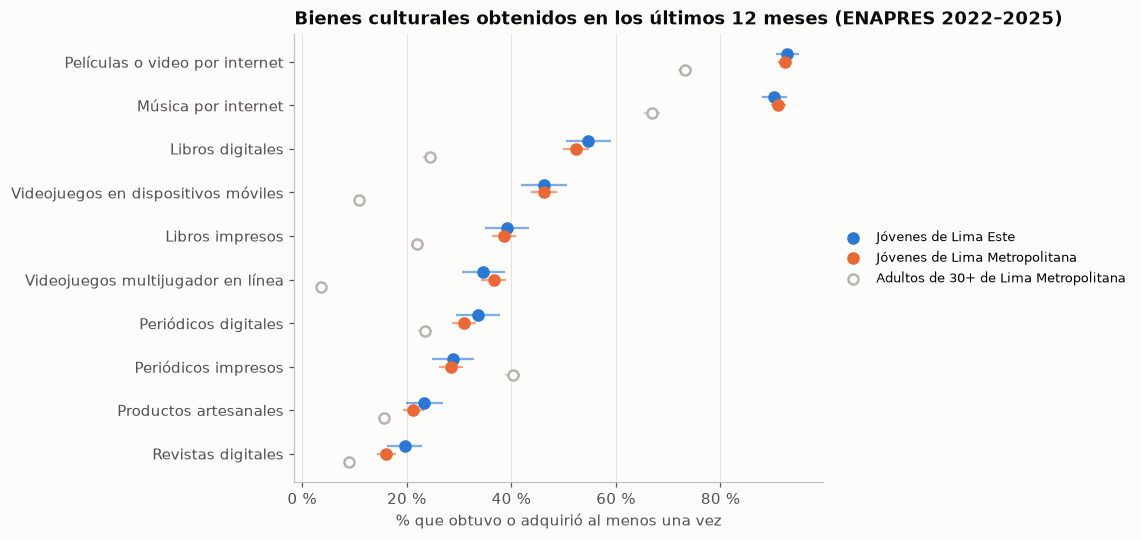

In [5]:
grafico_cul("bienes_culturales", "Bienes culturales obtenidos en los últimos 12 meses (ENAPRES 2022–2025)",
            "% que obtuvo o adquirió al menos una vez",
            excluir=["Otros productos culturales", "Música en CD", "Videojuegos en consola/CD", "Obras de arte",
                     "Películas o video en CD/Blu-ray", "Revistas impresas"])

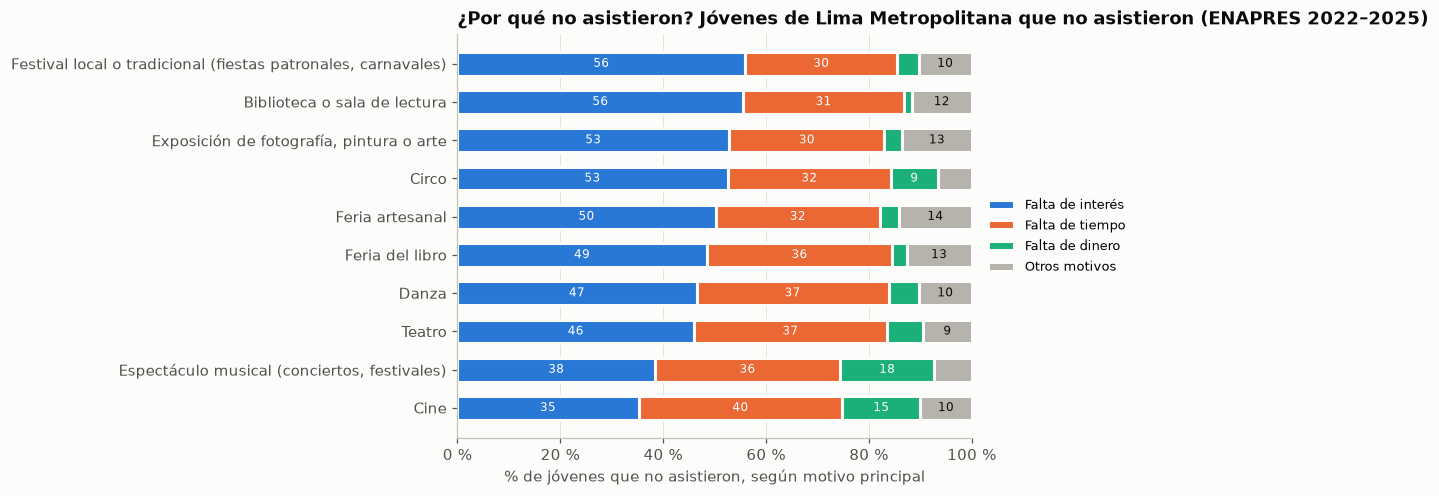

Motivo principal de no asistencia (%), jóvenes de 15-29, 2022-2025


nivel_geografico                                                    lima_este                                                                                    lima_metropolitana                   \
categoria                                                     Falta de dinero Falta de interés Falta de tiempo No hay ofertas No tiene información oportuna Otra    Falta de dinero Falta de interés   
item                                                                                                                                                                                                   
Biblioteca o sala de lectura                                                              55.8            31.8                                        8.5 r                   1.6 r             55.6   
Cine                                                                     18.8             42.4            31.6            0.0                                                  15.2             35.3   
Circo                                                                    10.9             52.3            28.9                                        3.8 r                     9.1             52.6   
Danza                                                                   5.7 r             46.1            37.6                                        7.7 r                     5.9             46.5   
Espectáculo musical (conciertos, festivales)                             21.2             40.8            31.9                                        3.5 r                    18.4             38.5   
Exposición de fotografía, pintura o arte                                4.3 r             54.2            30.3                                          8.8                     3.4             52.9   
Feria artesanal                                                         4.9 r             46.0            34.0                                         12.6                     3.8             50.2   
Feria del libro                                                         3.3 r             45.7            37.2                                         11.6                     2.8             48.5   
Festival local o tradicional (fiestas patronales, carnavales)           5.0 r             54.5            30.3                                        5.6 r                     4.2             56.0   
Otros servicios culturales                                                                                                                                                                             
Teatro                                                                  7.0 r             45.4            37.1                                        7.3 r                     7.1             46.1   

nivel_geografico                                                                                                                   
categoria                                                     Falta de tiempo No hay ofertas No tiene información oportuna   Otra  
item                                                                                                                               
Biblioteca o sala de lectura                                             31.1          1.8 r                           7.5  2.3 r  
Cine                                                                     39.6                                        2.0 r    7.6  
Circo                                                                    31.8          1.3 r                           2.7  2.6 r  
Danza                                                                    37.3          1.4 r                           6.9  1.9 r  
Espectáculo musical (conciertos, festivales)                             35.9                                        2.6 r    3.6  
Exposición de fotografía, pintura o arte                                 30.2          1.2 r                          10.3  2.0 r  
Feria artes

Entrada libre entre los jóvenes que asistieron (%)


nivel_geografico,lima_este,lima_metropolitana
item,,
Biblioteca o sala de lectura,96.0,97.9
Cine,,
Circo,,
Danza,65.7,68.7
"Espectáculo musical (conciertos, festivales)",22.2 r,21.2
"Exposición de fotografía, pintura o arte",91.4,77.6
Feria artesanal,90.5,91.8
Feria del libro,76.9,75.5
"Festival local o tradicional (fiestas patronales, carnavales)",92.7,91.6


In [6]:
mot = ag[(ag.familia == "motivo_no_asistencia") & (ag.grupo_edad == "15-29") & (ag.nivel_geografico == "lima_metropolitana")]
m = mot.pivot_table(index="item", columns="categoria", values="valor")
m["Otros motivos"] = m[["No tiene información oportuna", "No hay ofertas", "Otra"]].sum(axis=1)
m = m.drop(index=["Otros servicios culturales"], errors="ignore").sort_values("Falta de interés")
partes = [("Falta de interés", AZUL), ("Falta de tiempo", NARANJA), ("Falta de dinero", AQUA), ("Otros motivos", GRIS_SERIE)]
fig, ax = plt.subplots(figsize=(10.5, 4.6))
izq = np.zeros(len(m))
for nombre, color in partes:
    ax.barh(m.index, m[nombre], left=izq, color=color, height=0.62, edgecolor=FONDO, linewidth=2, label=nombre)
    for y, (v, x0) in enumerate(zip(m[nombre], izq)):
        if v >= 8:
            ax.text(x0 + v / 2, y, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if color != GRIS_SERIE else TINTA)
    izq += m[nombre].to_numpy()
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False); ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f} %")
ax.set_title("¿Por qué no asistieron? Jóvenes de Lima Metropolitana que no asistieron (ENAPRES 2022–2025)")
ax.set_xlabel("% de jóvenes que no asistieron, según motivo principal")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5)
plt.tight_layout(); plt.show()
print("Motivo principal de no asistencia (%), jóvenes de 15-29, 2022-2025")
display(tabla(ag[(ag.familia == "motivo_no_asistencia") & (ag.grupo_edad == "15-29")], "item", ["nivel_geografico", "categoria"]))
print("Entrada libre entre los jóvenes que asistieron (%)")
display(tabla(ag[(ag.familia == "forma_de_entrada") & (ag.categoria == "Entrada libre") & (ag.grupo_edad == "15-29")],
              "item", "nivel_geografico"))

In [7]:
anual = cul[(cul.familia == "asistencia") & (cul.categoria == "Sí") & (cul.grupo_edad == "15-29")
            & (cul.nivel_geografico == "lima_metropolitana") & (cul.periodo != "2022-2025")]
print("Jóvenes de Lima Metropolitana: asistencia por año (%)")
display(tabla(anual, "item", "periodo"))
sx = cul[(cul.periodo == "2022-2025") & (cul.grupo_edad == "15-29") & (cul.categoria == "Sí")
         & cul.familia.isin(["asistencia", "bienes_culturales"]) & (cul.nivel_geografico == "lima_metropolitana")]
print("Jóvenes de Lima Metropolitana por sexo, 2022-2025 (%)")
display(tabla(sx, ["familia", "item"], "sexo"))

Jóvenes de Lima Metropolitana: asistencia por año (%)


periodo,2022,2023,2024,2025
item,,,,
"Algún espectáculo o exposición en vivo (teatro, danza, circo, música, arte)",34.6,48.9,48.9,50.2
Algún servicio cultural (cualquiera de los 11),67.0,85.1,87.0,84.2
Biblioteca o sala de lectura,4.1 r,11.4,14.8,11.4
Cine,48.2,72.1,75.1,70.5
Circo,6.1 r,10.7,9.9 r,10.4 r
Danza,12.2,17.7,18.6,14.0
"Espectáculo musical (conciertos, festivales)",18.3,29.3,27.1,32.6
"Exposición de fotografía, pintura o arte",5.6 r,10.7,12.5,10.5
Feria artesanal,13.2,24.1,24.0,20.8


Jóvenes de Lima Metropolitana por sexo, 2022-2025 (%)


sexo                                                                                     hombre  mujer total
familia           item                                                                                      
asistencia        Algún espectáculo o exposición en vivo (teatro, danza, circo, músic...   43.0   48.3  45.6
                  Algún servicio cultural (cualquiera de los 11)                           80.5   81.0  80.7
                  Biblioteca o sala de lectura                                             10.5   10.3  10.4
                  Cine                                                                     65.9   66.8  66.4
                  Circo                                                                     7.7   10.9   9.2
                  Danza                                                                    14.8   16.5  15.6
                  Espectáculo musical (conciertos, festivales)                             25.2   28.4  26.8
                  Exposición de fotografía, pintura o arte                                  8.2   11.5   9.8
                  Feria artesanal                                                          18.0   23.1  20.5
                  Feria del libro                                                          16.2   18.8  17.5
                  Festival local o tradicional (fiestas patronales, carnavales)            13.4   16.7  15.0
                  Otros servicios culturales                                                5.6  4.9 r   5.3
                  Teatro                                                                    9.5   12.3  10.8
bienes_culturales Libros digitales                                                         47.6   57.5  52.4
                  Libros impresos                                                          37.3   40.0  38.6
                  Música en CD                                                            2.6 r  3.8 r   3.2
                  Música por internet                                                      92.4   89.7  91.1
                  Obras de arte                                                             6.0    8.6   7.3
                  Otros productos culturales                                                8.4    7.4   7.9
                  Películas o video en CD/Blu-ray                                           7.4    6.9   7.1
                  Películas o video por internet                                           91.9   92.6  92.3
                  Periódicos digitales                                                     31.5   30.3  30.9
                  Periódicos impresos                                                      30.2   26.7  28.5
                  Productos artesanales                                                    20.0   22.7  21.3
                  Revistas digitales                                                       12.5   20.0  16.1
                  Revistas impresas                                                         6.7    7.7   7.2
                  Videojuegos en consola/CD                                                 6.7          4.4
                  Videojuegos en dispositivos móviles                                      58.1   33.9  46.3
                  Videojuegos multijugador en línea                                        51.2   21.2  36.6

### 2.1 Lectura

- **El cine es la salida cultural más extendida** entre los jóvenes (alrededor de 6 de cada 10 en 2022–2025,
  el doble que entre los adultos). Le siguen los **espectáculos musicales** (cerca de 1 de cada 4 en Lima
  Metropolitana y 21 % en Lima Este) y las ferias artesanales o del libro, la danza y los festivales locales o
  tradicionales (15–21 % cada uno).
- **La mayor distancia con los adultos** está en bibliotecas, ferias del libro, museos y espectáculos en vivo:
  los jóvenes son el público más activo de casi todos los servicios culturales.
- **El consumo cultural es principalmente digital:** más de 9 de cada 10 jóvenes obtuvo video y música por
  internet, más de la mitad libros digitales, cerca de la mitad **videojuegos en el celular** y un tercio
  **videojuegos multijugador en línea** (entre adultos, 11 % y 4 %).
- **Barreras:** entre quienes no asistieron, el motivo principal es la **falta de interés** (35–56 % según el
  servicio) seguida de la **falta de tiempo** (30–40 %). **El dinero pesa sobre todo en el cine y los
  conciertos** (15–21 %). "No hay oferta" casi no aparece (≈ 1–2 %) y la falta de información es relevante en
  ferias y exposiciones (8–13 %).
- **Gratuidad:** la mayoría de asistentes jóvenes entró gratis a bibliotecas, ferias, festivales y exposiciones;
  en cambio, casi 8 de cada 10 asistentes a conciertos y cerca de 7 de cada 10 al teatro tuvieron una entrada
  pagada (por ellos o por otra persona).
- Lima Este sigue el mismo patrón que el conjunto metropolitano: sus intervalos de confianza se superponen con
  los de Lima Metropolitana en todos los servicios.

## 3. Internet, aprendizaje y motivos para no estudiar — ENAHO 2022–2025

Jóvenes de 15–29 años. **Validación con Dato Joven:** uso de internet ±0,2 puntos y asistencia universitaria
(17–24) ±1 punto en 2022–2025.

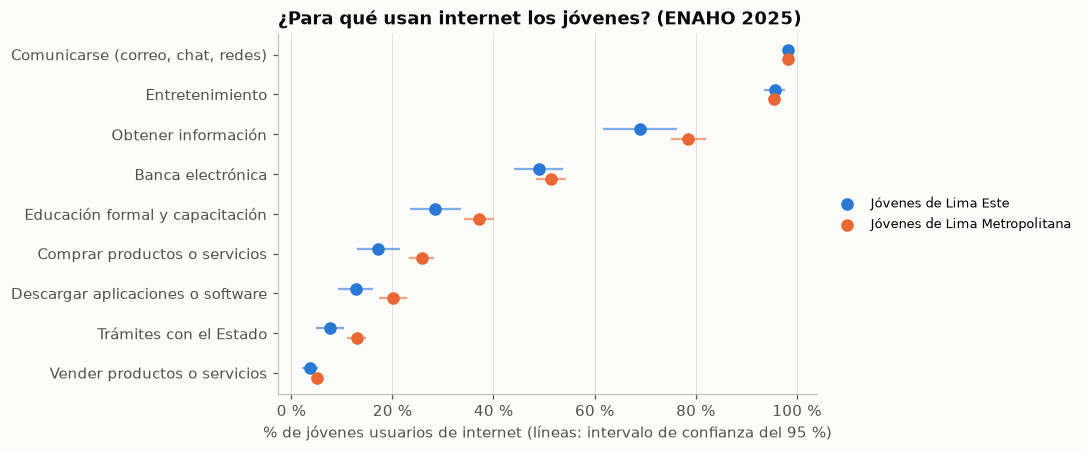

Propósitos de uso de internet por edad, Lima Metropolitana 2025 (%)


grupo_edad,15-19,15-29,20-24,25-29
categoria,,,,
Banca electrónica,23.9,51.4,59.0,65.7
Comprar productos o servicios,12.6,25.8,26.4,35.3
"Comunicarse (correo, chat, redes)",96.5,98.3,99.3,98.7
Descargar aplicaciones o software,17.2,20.2,21.7,21.2
Educación formal y capacitación,37.8,37.1,43.1,31.6
Entretenimiento,95.5,95.4,96.9,94.1
Obtener información,73.7,78.6,80.6,80.6
Trámites con el Estado,5.6 r,12.9,15.8,16.0
Vender productos o servicios,2.9 r,5.0,5.1 r,6.6 r


Educación formal y capacitación como uso de internet, por año (%)


periodo,2022,2022-2025,2023,2024,2025
nivel_geografico,,,,,
lima_este,34.0,32.7,33.8,34.5,28.5
lima_metropolitana,36.7,35.5,32.1,36.1,37.1
nacional,33.2,,29.8,30.8,30.4


In [8]:
edu = pd.read_csv(P / "capa2_educacion_internet_enaho.csv")
e25 = edu[(edu.periodo == "2025") & (edu.sexo == "total") & (edu.grupo_edad == "15-29")]
def serie_edu(df, fam, geo):
    d = df[(df.familia == fam) & (df.nivel_geografico == geo)].set_index("categoria"); return d.valor_publicable, d.ee
datos = {}
for nombre, geo in [("Jóvenes de Lima Este", "lima_este"), ("Jóvenes de Lima Metropolitana", "lima_metropolitana")]:
    datos[nombre], datos[f"{nombre}_ee"] = serie_edu(e25, "proposito_internet", geo)
cats = datos["Jóvenes de Lima Metropolitana"].sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(10, 4.2))
puntos(ax, datos, cats, [("Jóvenes de Lima Este", AZUL, False), ("Jóvenes de Lima Metropolitana", NARANJA, False)],
       "% de jóvenes usuarios de internet (líneas: intervalo de confianza del 95 %)",
       "¿Para qué usan internet los jóvenes? (ENAHO 2025)", ic=True)
plt.tight_layout(); plt.show()
print("Propósitos de uso de internet por edad, Lima Metropolitana 2025 (%)")
display(tabla(edu[(edu.periodo == "2025") & (edu.sexo == "total") & (edu.nivel_geografico == "lima_metropolitana")
                  & (edu.familia == "proposito_internet")], "categoria", "grupo_edad"))
print("Educación formal y capacitación como uso de internet, por año (%)")
display(tabla(edu[(edu.categoria == "Educación formal y capacitación") & (edu.sexo == "total") & (edu.grupo_edad == "15-29")],
              "nivel_geografico", "periodo"))

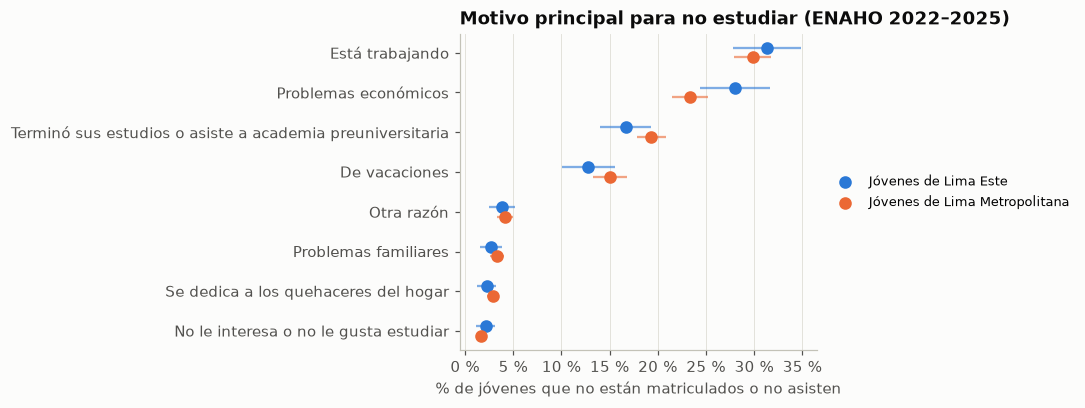

Asistencia actual y nivel (%), 2022-2025


nivel_geografico                                                  lima_este lima_metropolitana
familia          categoria                                                                    
educacion        Asiste actualmente a educación básica o superior      35.4               33.4
nivel_asistencia Básica especial                                        0.0                   
                 Maestría/doctorado                                                      0.7 r
                 Primaria                                                                     
                 Secundaria                                            37.8               34.1
                 Superior no universitaria                             20.0               21.1
                 Superior universitaria                                41.5               43.9

Motivo principal para no estudiar por sexo, Lima Metropolitana 2022-2025 (%)


sexo,hombre,mujer,total
categoria,,,
Asiste a un centro de enseñanza no regular,,,
Asiste a un centro técnico-productivo (CETPRO),,,
De vacaciones,15.6,14.5,15.1
Está trabajando,35.8,23.5,29.9
Institución no licenciada,0.0,,
No le gustan o no aprende en clases virtuales,,,
No le interesa o no le gusta estudiar,2.3 r,,1.6 r
Otra razón,4.8,3.5,4.2
Problemas económicos,20.2,26.7,23.3


In [9]:
agr = edu[(edu.periodo == "2022-2025") & (edu.sexo == "total") & (edu.grupo_edad == "15-29")]
datos = {}
for nombre, geo in [("Jóvenes de Lima Este", "lima_este"), ("Jóvenes de Lima Metropolitana", "lima_metropolitana")]:
    datos[nombre], datos[f"{nombre}_ee"] = serie_edu(agr, "motivo_no_asistencia", geo)
cats = [c for c in datos["Jóvenes de Lima Metropolitana"].sort_values(ascending=False).index
        if pd.notna(datos["Jóvenes de Lima Metropolitana"][c]) and datos["Jóvenes de Lima Metropolitana"][c] >= 1]
fig, ax = plt.subplots(figsize=(10, 3.8))
puntos(ax, datos, cats, [("Jóvenes de Lima Este", AZUL, False), ("Jóvenes de Lima Metropolitana", NARANJA, False)],
       "% de jóvenes que no están matriculados o no asisten", "Motivo principal para no estudiar (ENAHO 2022–2025)", ic=True)
plt.tight_layout(); plt.show()
print("Asistencia actual y nivel (%), 2022-2025")
display(tabla(agr[agr.familia.isin(["educacion", "nivel_asistencia"])], ["familia", "categoria"], "nivel_geografico"))
print("Motivo principal para no estudiar por sexo, Lima Metropolitana 2022-2025 (%)")
display(tabla(edu[(edu.periodo == "2022-2025") & (edu.nivel_geografico == "lima_metropolitana") & (edu.grupo_edad == "15-29")
                  & (edu.familia == "motivo_no_asistencia")], "categoria", "sexo"))

### 3.1 Lectura

- **Internet es sobre todo comunicación y entretenimiento** (95–98 %). Para **educación formal y capacitación**
  lo usa alrededor de un tercio de los jóvenes (35,5 % en Lima Metropolitana y 32,7 % en Lima Este, 2022–2025).
  En 2025 Lima Este aparece más baja (28,5 % frente a 37,1 %), pero en 2022–2024 sus valores fueron similares a los
  metropolitanos, así que **no se puede afirmar una brecha estable**. El uso para informarse y comprar también
  aparece algo menor en Lima Este en 2025.
- **Por edad:** el uso educativo es mayor entre 20 y 24 años (43 %); la banca electrónica y las compras crecen con
  la edad; vender por internet sigue siendo minoritario (≈ 5 %).
- **Por qué no estudian:** los principales motivos son **estar trabajando** (≈ 30 %) y **problemas económicos**
  (23 % en Lima Metropolitana y algo más en Lima Este, 28 %, en 2022–2025); en las mujeres pesan más los problemas
  económicos, los familiares y los quehaceres del hogar. **La falta de interés en estudiar es mínima (≈ 2 %)**: la barrera no es
  la motivación sino el costo y el tiempo.

## 4. Aspiraciones, diversión y consumo — estudios de Ipsos (Perú urbano, 2019–2022)

Cifras transcritas de las infografías públicas (`fuentes/capa2_estudios_ipsos.csv`). **Población y años
distintos a los del proyecto:** 13–20 años (2019, 2020) y 18–25 años (2022), Perú urbano. Sirven para identificar
**dimensiones** (qué preguntar, qué explorar), no para describir a los jóvenes de Lima Este en 2026.

In [10]:
ips = pd.read_csv(Path("..") / "fuentes" / "capa2_estudios_ipsos.csv")
print(ips.groupby(["id_fuente", "estudio", "trabajo_de_campo", "poblacion", "cobertura", "muestra"]).size()
      .rename("cifras").reset_index().to_string(index=False))
for tema in ["Diversión fuera de casa", "Diversión dentro de casa", "Trabajo ideal", "Planes y aspiraciones",
             "Emprendimiento", "Exposición a medios", "Entretenimiento en casa", "Redes sociales"]:
    d = ips[ips.tema == tema]
    print(f"\n{tema} ({d.estudio.iloc[0][:45]}…; base: {d.base.iloc[0]})")
    print(d[["indicador", "valor_pct"]].to_string(index=False, header=False))

id_fuente                                                       estudio                               trabajo_de_campo                                      poblacion                               cobertura   muestra  cifras
    C2-02    Gen Z: Perfil del adolescente y joven del Perú urbano 2019                          23/05/2019–16/06/2019                     13–20 años (todos los NSE)                             Perú urbano      1003      26
    C2-03         Perfil del adolescente y joven en el Perú Urbano 2020 27/02/2020–15/03/2020 (antes de la cuarentena)                     13–20 años (todos los NSE) 11 principales ciudades del Perú urbano       995      18
    C2-04 Generaciones en el Perú 2022 (Perfil de la Generación Z 2022)               Estudios multiclientes 2021–2022 Generación Z de 18–25 años (nacidos 1997–2009)       Perú urbano (según la infografía) No indica       6

Diversión fuera de casa (Gen Z: Perfil del adolescente y joven del Per…; base: Total)
                 

### 4.1 Lectura (señales, no estimaciones actuales)

- **Aspiraciones laborales con fuerte orientación al emprendimiento:** en 2020, el 45 % de los adolescentes y
  jóvenes urbanos (13–20) aspiraba a tener su propio negocio y el 39 % a trabajar en algo que le apasione; en 2019,
  el 60 % de los de 18–20 sin negocio deseaba emprender (solo el 4 % tenía uno).
- **Desajuste estudios–trabajo:** entre quienes trabajaban (2020), solo el 23 % lo hacía en algo relacionado
  con su carrera.
- **Diversión fuera de casa** (2019): salir a comer, parques, visitar amigos y **hacer ejercicio** (42–44 %), y
  cine (37 %). Dentro de casa: YouTube, televisión, redes y música por aplicaciones.
- **Gen Z adulta (18–25, 2022):** videojuegos como entretenimiento en casa (32 %), alta presencia en TikTok
  (55 %) y Discord (24 %), y disposición al ahorro formal.
- Estas señales coinciden con la evidencia representativa reciente (peso de lo digital, videojuegos, deporte,
  cine) y añaden una dimensión que las encuestas del INEI no miden: **el deseo de emprender**.

## 5. Señales exploratorias de la Capa 1 (Lima Este)

Recordatorio de la Capa 1, **sin generalizar**:
- **Programa de Voluntariado Juvenil** (1 727 personas inscritas de los 7 distritos): los intereses declarados
  casi no discriminan (81–93 % marca "sí" en cada temática). La **experiencia previa** sí diferencia: educación
  (39 %), medio ambiente (31 %), cultura (23 %) y salud (20 %), por encima de deporte (11 %).
- **RENOJ:** las organizaciones juveniles acreditadas de Lima Este se concentran en educación y desarrollo,
  acción social y voluntariado, y cultura y arte; **no hay ninguna de deporte**, pese a que el deporte es una de
  las actividades más practicadas por los jóvenes (sección 1).

## 6. Síntesis: temáticas con potencial de convocatoria

Esta tabla **no diseña actividades**: ordena la evidencia sobre intereses y barreras para el cruce posterior con
la Capa 1 (necesidades) y la Capa 3 (oferta).

| Temática | Evidencia de interés o práctica | Nivel y fuerza de la evidencia | Barreras o matices |
|---|---|---|---|
| **Cultura digital y videojuegos** | 92 % usa dispositivos cada semana; ~46 % videojuegos en el celular y ~35 % multijugador en línea; Discord/TikTok | Representativa (Lima Metropolitana y Lima Este) + Ipsos | Consumo individual y en casa; no indica interés en actividades grupales |
| **Cine y audiovisual** | Salida cultural más extendida (~6 de cada 10); 93 % ve video por internet | Representativa, Lima Este incluida | El dinero es barrera para ~1 de cada 5 de quienes no van |
| **Música en vivo** | Cerca de 1 de cada 4 asistió a conciertos o festivales en Lima Metropolitana (21 % en Lima Este) | Representativa | Mayormente pagado; el dinero pesa |
| **Deporte y ejercicio** | 35 % lo practica cada semana (49 % de los hombres); "hacer ejercicio" 42 % en Ipsos | Representativa (Lima Este: 28 %) | Gran brecha de género; **no hay organizaciones juveniles de deporte** en el RENOJ de Lima Este |
| **Lectura y ferias del libro** | Más de la mitad obtuvo libros digitales; ~1 de cada 5 fue a una feria del libro | Representativa | Leer como actividad semanal es poco frecuente (10–13 %) |
| **Artes, danza y aficiones** | Danza (~18 %), aficiones y artes (18–19 % semanal) | Representativa | Falta de interés como motivo principal de no asistencia |
| **Festivales locales y ferias** | ~1 de cada 5 asistió; casi siempre con entrada libre | Representativa | Evento puntual |
| **Aprendizaje y capacitación** | Alrededor de un tercio usa internet para educación o capacitación; casi nadie deja de estudiar por falta de interés | Representativa, Lima Este incluida | Trabajo y problemas económicos impiden estudiar |
| **Emprendimiento** | 45 % aspira a negocio propio; 60 % de 18–20 desea emprender | Solo Ipsos, 2019–2020, 13–20 años | Sin dato representativo reciente ni local |
| **Tiempo libre y socialización** | Menos de la mitad satisfecho con su tiempo libre; en Lima Este, más insatisfacción con el tiempo para amistades | Representativa (una sola ola, 2024) | El tiempo es escaso: la mitad estudia ~37 h y la mitad trabaja ~42 h |

**Qué no se puede afirmar:** preferencias por distrito; interés en actividades específicas que las encuestas
no preguntan (por ejemplo, talleres concretos); tendencias 2022–2025 en Lima Este (la muestra se agrupó);
aspiraciones actuales representativas (el único dato de emprendimiento es de Ipsos, 2019–2020).